# 03 · PJM Energy Demand — Time-Series Foundations (stationarity, ACF/PACF, MSTL)

## Part 3 — Time-Series Foundations

The formal TS toolkit applied to the load series: **stationarity** testing (and the trap that
seasonality sets for it), the **ACF/PACF** correlation structure, and a full **MSTL** decomposition
that separates the trend, the daily and weekly seasonals, and the remainder. These are the diagnostics
every forecasting choice in Parts 7–9 rests on.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 130, "display.max_columns", 40)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import MSTL, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
d = data.clean_primary(); s = d.load_mw
print("series:", len(s), "hourly points")

setup ok | numpy 2.1.3 | pandas 2.3.3


series: 145392 hourly points


### 1. Stationarity — and why the two tests disagree

A **stationary** series has constant mean/variance over time — many models assume it. We run two tests
with *opposite* null hypotheses:
- **ADF** (null = has a unit root / non-stationary),
- **KPSS** (null = stationary).

On the raw series they **conflict**: ADF rejects its null (→ "stationary") while KPSS *also* rejects
its null (→ "non-stationary"). This classic disagreement is the fingerprint of **strong seasonality +
mild trend**: the series is mean-reverting (no unit root) but its mean *moves with the season*, which
KPSS detects. The fix is to remove the seasonality.

In [2]:
def report(x, label):
    a = adfuller(x, maxlag=48, autolag=None); k = kpss(x, nlags=48)
    print("%-22s ADF p=%6.3g (%s) | KPSS p=%5.3g (%s)" %
          (label, a[1], "stationary" if a[1]<.05 else "non-stat",
                  k[1], "non-stat" if k[1]<.05 else "stationary"))
report(s.values, "raw level")
report(s.diff(24).dropna().values, "seasonal diff (lag 24)")
print("\n-> raw: tests CONFLICT (seasonality fools KPSS). After seasonal differencing they AGREE: stationary.")

C:\Users\parth\AppData\Local\Temp\ipykernel_8932\645295733.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  a = adfuller(x, maxlag=48, autolag=None); k = kpss(x, nlags=48)


raw level              ADF p=     0 (stationary) | KPSS p= 0.01 (non-stat)


seasonal diff (lag 24) ADF p=     0 (stationary) | KPSS p=  0.1 (stationary)

-> raw: tests CONFLICT (seasonality fools KPSS). After seasonal differencing they AGREE: stationary.


C:\Users\parth\AppData\Local\Temp\ipykernel_8932\645295733.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  a = adfuller(x, maxlag=48, autolag=None); k = kpss(x, nlags=48)


### 2. ACF & PACF — the correlation skeleton

The **autocorrelation function** shows demand correlating with its past at every lag: huge spikes at
**multiples of 24** (daily) with a slow weekly envelope. The **partial ACF** isolates the direct
effect of each lag — a strong lag-1 and lag-24 dominate, which is why AR-type and lag-feature models
work so well.

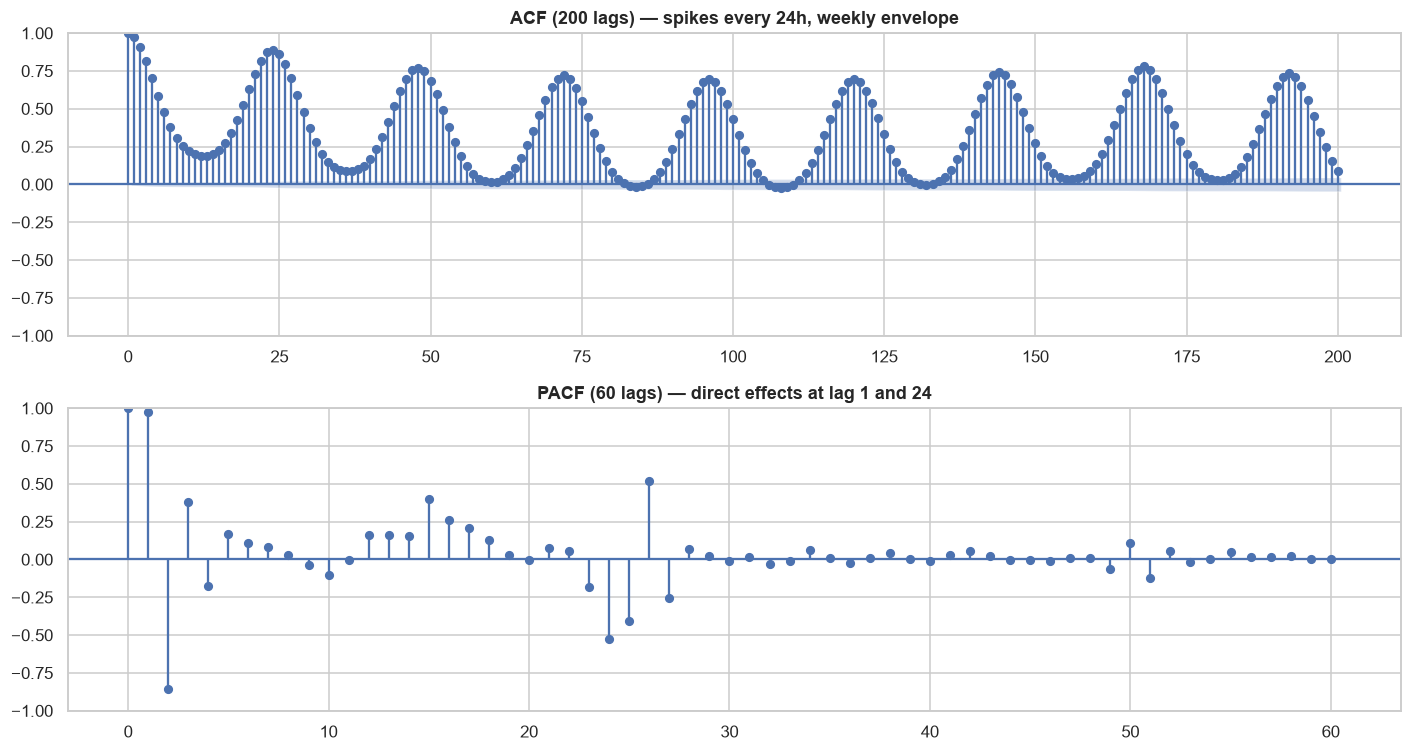

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(13, 7))
plot_acf(s.values, lags=200, ax=ax[0]); ax[0].set_title("ACF (200 lags) — spikes every 24h, weekly envelope")
plot_pacf(s.values, lags=60, ax=ax[1], method="ywm"); ax[1].set_title("PACF (60 lags) — direct effects at lag 1 and 24")
fig.tight_layout(); eda.savefig(fig, "p3_acf_pacf.png"); plt.show()

### 3. MSTL — decomposing *multiple* seasonalities

Ordinary STL handles one seasonal cycle; **MSTL** peels off several. We extract the **daily (24h)** and
**weekly (168h)** seasonals simultaneously, leaving a smooth **trend** and a **remainder**. Shown over
three weeks so the components are legible. The **seasonal strength** (share of variance each explains)
confirms the daily cycle dominates.

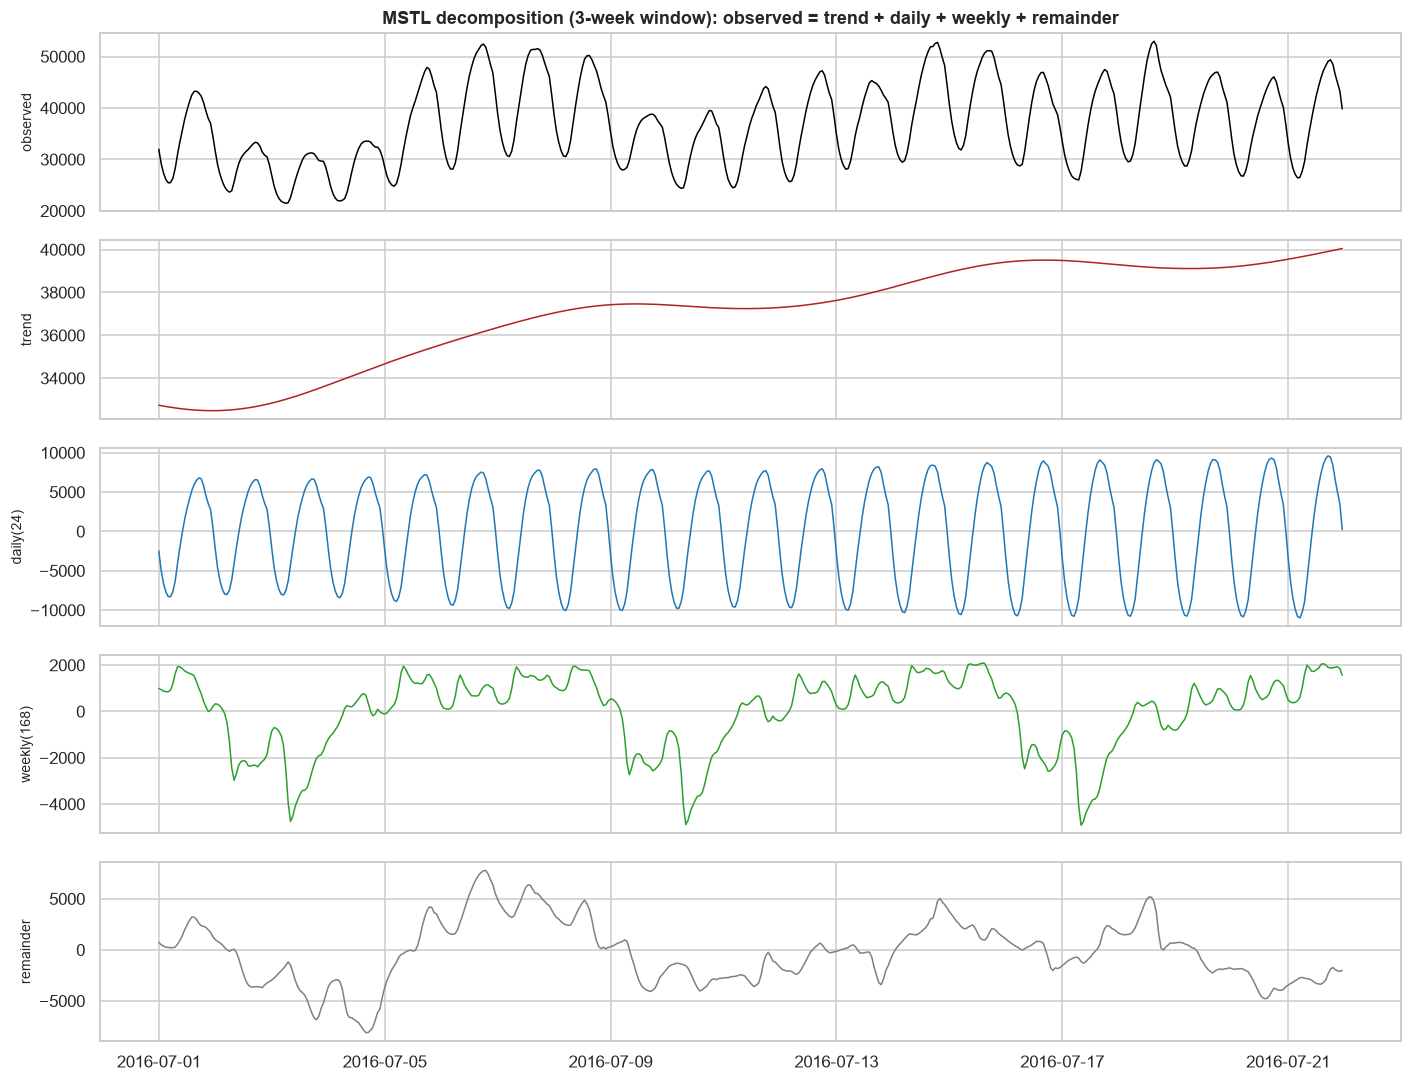

seasonal strength — daily 0.86 | weekly 0.53 | remainder share of var 7.3%


In [4]:
res = MSTL(s, periods=(24, 168)).fit()
win = slice("2016-07-01", "2016-07-21")
comp = pd.DataFrame({"observed": s, "trend": res.trend,
                     "daily(24)": res.seasonal["seasonal_24"], "weekly(168)": res.seasonal["seasonal_168"],
                     "remainder": res.resid})
fig, axes = plt.subplots(5, 1, figsize=(13, 10), sharex=True)
for ax, c, col in zip(axes, comp.columns, ["black","firebrick","tab:blue","tab:green","grey"]):
    ax.plot(comp.loc[win].index, comp.loc[win, c], color=col, lw=1); ax.set_ylabel(c, fontsize=9)
axes[0].set_title("MSTL decomposition (3-week window): observed = trend + daily + weekly + remainder")
fig.tight_layout(); eda.savefig(fig, "p3_mstl.png"); plt.show()
def strength(seas): return max(0, 1 - res.resid.var()/(res.resid + seas).var())
print("seasonal strength — daily %.2f | weekly %.2f | remainder share of var %.1f%%" %
      (strength(res.seasonal["seasonal_24"]), strength(res.seasonal["seasonal_168"]), 100*res.resid.var()/s.var()))

### 4. The annual cycle

MSTL on hourly data captures the sub-weekly seasonals; the **annual** cycle is clearest on the
**daily-mean** series. An STL with a 365-day period extracts the **bimodal** yearly seasonal (the
summer and winter humps) on top of the slowly declining trend.

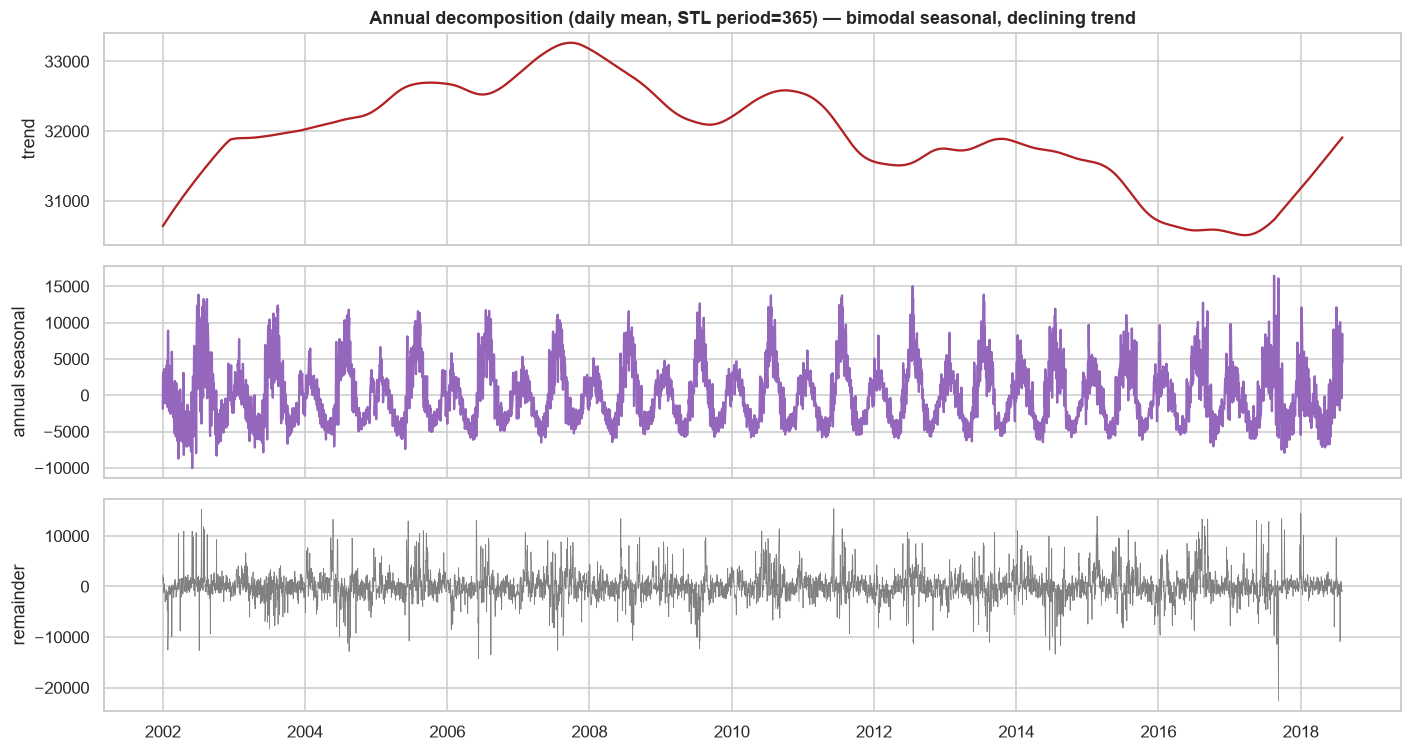

annual seasonal swing: 26505 MW peak-to-peak


In [5]:
daily = s.resample("D").mean()
stl = STL(daily, period=365, robust=True).fit()
fig, ax = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
ax[0].plot(daily.index, stl.trend, color="firebrick"); ax[0].set_ylabel("trend")
ax[1].plot(daily.index, stl.seasonal, color="tab:purple"); ax[1].set_ylabel("annual seasonal")
ax[2].plot(daily.index, stl.resid, color="grey", lw=.5); ax[2].set_ylabel("remainder")
ax[0].set_title("Annual decomposition (daily mean, STL period=365) — bimodal seasonal, declining trend")
fig.tight_layout(); eda.savefig(fig, "p3_annual_stl.png"); plt.show()
print("annual seasonal swing: %.0f MW peak-to-peak" % (stl.seasonal.max() - stl.seasonal.min()))

### Takeaways

- **Stationarity tests conflict** on the raw series (ADF stationary vs KPSS non-stationary) — the
  signature of strong seasonality; **seasonal differencing** (lag 24) makes them agree.
- The **ACF** shows clean 24-hour spikes under a weekly envelope; the **PACF** points to lag-1 and
  lag-24 as the direct drivers (AR / lag features will be strong).
- **MSTL** cleanly separates the **daily (dominant) and weekly** seasonals from a smooth trend; the
  remainder is a small share of variance.
- The **annual** cycle (via daily-mean STL) is **bimodal** atop a gently declining trend.

**Next — Part 4 (Spectral diagnostics):** confirm these cycles in the *frequency* domain with the
periodogram/FFT, watch them with a spectrogram, and probe long-memory.